# Internship Project — Week 1

# House Price Prediction

# Library loading

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset Loading

In [2]:
df = pd.read_csv("Housing.csv")

In [3]:
df.head(10) # Displays first 10 rows

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


In [5]:
df.shape # Checks no. of rows and columns

(545, 13)

In [6]:
# Price is the target column

In [7]:
X = df.drop("price", axis=1)
y = df["price"]

In [9]:
X.columns # verifying if price column is removed

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
       'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
       'furnishingstatus'],
      dtype='object')

In [10]:
df.isna() # checks columns with missing values

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,False,False,False,False,False,False,False,False,False,False,False,False,False
541,False,False,False,False,False,False,False,False,False,False,False,False,False
542,False,False,False,False,False,False,False,False,False,False,False,False,False
543,False,False,False,False,False,False,False,False,False,False,False,False,False


In [11]:
df.isna().sum() # checks no. of missing values in each column (including price)

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [12]:
df.info() #dataset info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [13]:
df.describe() # dataset summary

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


# Data Cleaning 

In [14]:
df = df.drop_duplicates()

In [16]:
df.duplicated().sum() # checks for no. of duplicated columns

np.int64(0)

In [17]:
df.select_dtypes(include='object').columns # to identify categorical columns

Index(['mainroad', 'guestroom', 'basement', 'hotwaterheating',
       'airconditioning', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [18]:
# One-hot encoding

In [19]:
encoded_df = pd.get_dummies(df,drop_first=True)

In [20]:
encoded_df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [21]:
X = encoded_df.drop("price", axis=1)
y = encoded_df["price"]

In [23]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes',
       'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='object')

# NOTE: All available features were kept because they represent relevant characteristics that MAY influence house prices

In [25]:
# Dataset splitting
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42) # random_state for same splitting every time

# 1. Linear Regression Model

In [26]:
lr = LinearRegression()

In [27]:
lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [28]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
lr_pred = lr.predict(X_test)

In [30]:
print("MAE of Linear Regression:", mean_absolute_error(y_test, lr_pred))
print("RMSE of Linear Regression:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R^2 of Linear Regression:", r2_score(y_test, lr_pred))

MAE of Linear Regression: 970043.4039201635
RMSE of Linear Regression: 1324506.9600914384
R^2 of Linear Regression: 0.6529242642153186


# 2. Random Forest 

In [31]:
rf = RandomForestRegressor(n_estimators=100,random_state=42) # Random forest will contain 100 trees for better accuracy

In [32]:
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
rf_pred = rf.predict(X_test)

In [34]:
print("MAE of Random Forest:", mean_absolute_error(y_test, rf_pred))
print("RMSE of Random Forest:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R^2 of of Random Forest:", r2_score(y_test, rf_pred))

MAE of Random Forest: 1021546.0353211008
RMSE of Random Forest: 1400565.9728553821
R^2 of of Random Forest: 0.611918531405699


In [37]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

In [38]:
comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,9.700434e+05,1.324507e+06,0.652924
1,Random Forest,1.021546e+06,1.400566e+06,0.611919


# Linear Regression performed better than Random Forest on this dataset, achieving a higher R^2 score (0.653) and lower prediction errors (MAE and RMSE).

# Visualization 

# Histogram showing distribution of house prices

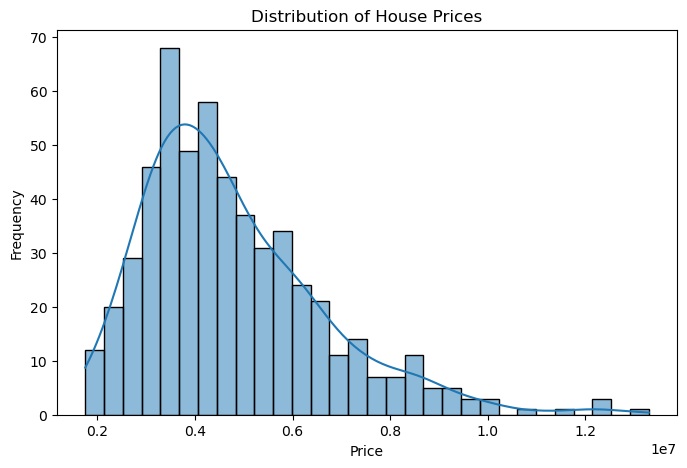

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.savefig("house_price_distribution.png")
plt.show()

# The histogram shows that house prices are not evenly distributed, i.e., ,ost properties fall within the lower to middle price range, while only a few houses have very high prices.

# 2. Correlation Heatmap

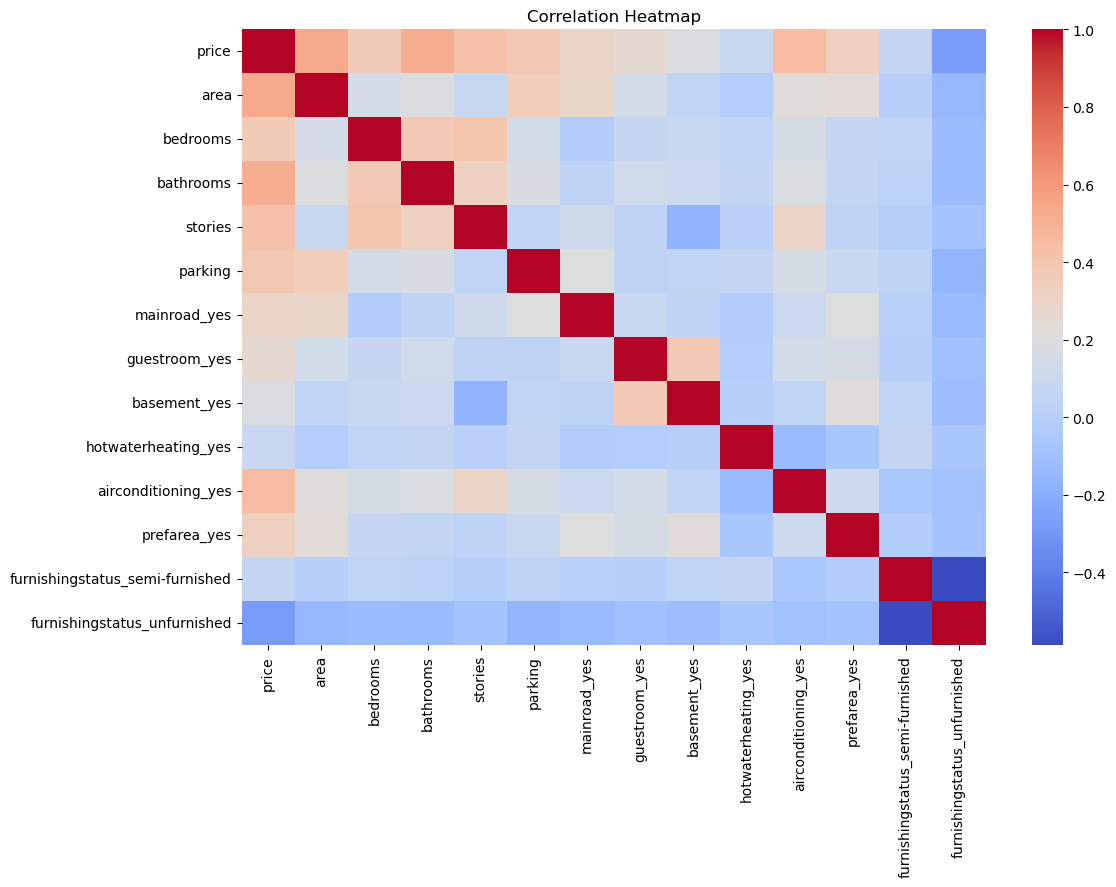

In [42]:
plt.figure(figsize=(12,8))
corr_matrix = encoded_df.corr()
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False
)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png")
plt.show()

# The heatmap was used to identify relationships between features and house prices. Features with stronger positive correlations have a greater influence on the final house price.

# Scatter Plot to compare actual and predicted house prices

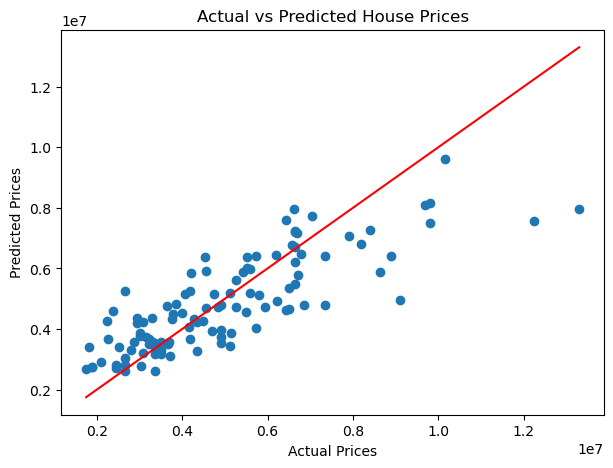

In [44]:
plt.figure(figsize=(7,5))
plt.scatter(y_test, lr_pred)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.savefig("actual_vs_predicted.png")
plt.show()

# The scatter plot compares actual house prices with the prices predicted by the Linear Regression model. The closer the points are to the red diagonal line, the more accurate the predictions.

In [45]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

In [46]:
importance = importance.sort_values(by="Importance",ascending=False)

In [47]:
importance.head(10)

,Feature,Importance
0,area,0.468430
2,bathrooms,0.151483
9,airconditioning_yes,0.062672
4,parking,0.057455
3,stories,0.057133
1,bedrooms,0.048413
12,furnishingstatus_unfurnished,0.035011
7,basement_yes,0.030823
10,prefarea_yes,0.030689
8,hotwaterheating_yes,0.017226


# Barplot

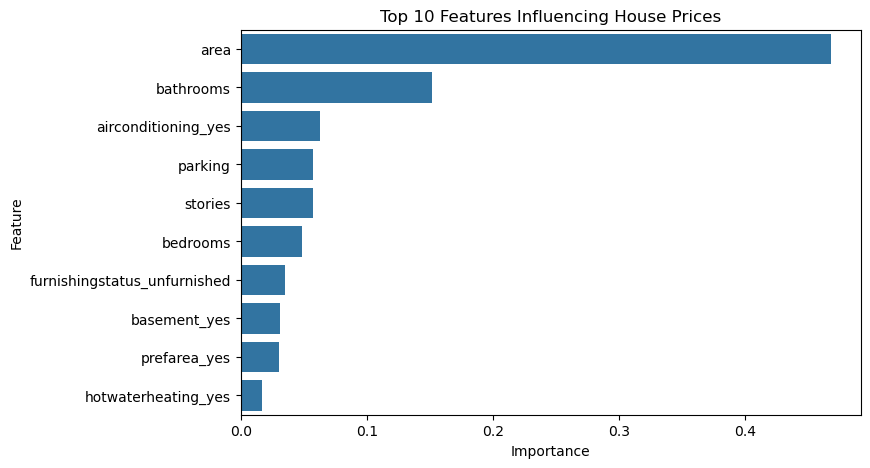

In [48]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Features Influencing House Prices")
plt.savefig("feature_importance.png")
plt.show()

# Insights and Summary

### The goal of this project was to develop a machine learning model capable of predicting house prices based on various property characteristics. 
### After analyzing the dataset and training two regression models, it was found that **Linear Regression outperformed Random Forest Regressor**, achieving an R² score of approximately **0.65**, which indicates that the model could explain about 65% of the variation in house prices. 
### Feature importance analysis showed that **area** was the most significant factor influencing house prices, followed by **number of bathrooms, air conditioning, parking availability, and number of stories**. One interesting observation was that the size of the property had a much stronger impact on price than several other amenities. 
### The Actual vs Predicted scatter plot demonstrated that the model was able to capture the overall pricing trend reasonably well, although prediction errors increased for some high-priced properties. 
### Based on these findings, real estate businesses should pay particular attention to property size and essential amenities when estimating prices, valuing properties, or designing marketing strategies.